# High-Dimensional Linear IV Regression: PGMM Methods

This notebook demonstrates the usage of:
- **Double Lasso** - Double Lasso IV estimator
- **PGMM Linear IV** - Penalized GMM for Linear IV Regression
- **PGMM Linear IV-CV** - Cross-validated penalty selection
- **A-PGMM Linear IV** - Adaptive PGMM with data-driven weights
- **A-PGMM Linear IV-CV** - Cross-validated adaptive PGMM

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sys
import os

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '../replication/linear_iv_model')))

from admliv.utils.featurizers import SimpleFeaturizer
from admliv.core.control import PGMMControl, PGMMCVControl
from admliv.core.pgmm_linear_iv import PGMMLinearIV
from admliv.core.pgmm_linear_iv_cv import PGMMLinearIVCV
from admliv.estimators.sieve import DoubleLassoEstimator, LassoStageControl, DoubleLassoControl

# Monte Carlo class
from mc_hd_linear_iv import MonteCarloHDLinearIV, MonteCarloConfig

np.random.seed(42)
print("Imports successful!")

Imports successful!


## 1. Data Generation

We generate data according to Belloni et al. (2012) exponential design:

$$Y = X'\beta_0 + \varepsilon, \quad \varepsilon \sim N(0, 1)$$
$$X = \Pi Z + v$$

where:
- $\beta_0 = (1, 1, 1, 0, \ldots, 0)$ (only 3 non-zero coefficients)
- $Z \sim N(0, \Sigma_Z)$ with $\text{Corr}(Z_h, Z_j) = 0.5^{|h-j|}$
- $\Pi_j = 0.7^{j-1}$ (exponentially declining first-stage coefficients)
- $v|\varepsilon \sim N(r\varepsilon \cdot \mathbf{1}, (1-r^2)I)$ (endogeneity with parameter $r = 0.5$)
- $n = 1000$ observations, $d_x = 100$ regressors, $d_z = 150$ instruments

In [2]:
def generate_data(n_obs=1000, dx=100, dz=150, n_nonzero=3, r=0.5, seed=42):
    """Generate high-dimensional linear IV regression data (Belloni et al. 2012 design)."""
    np.random.seed(seed)
    
    # True coefficients: β₀ = (1, 1, 1, 0, ..., 0)
    beta_0 = np.zeros(dx + 1)  # +1 for intercept
    beta_0[:n_nonzero] = 1.0
    
    # Generate Z ~ N(0, Σ_Z) with Toeplitz correlation
    Sigma_z = np.zeros((dz, dz))
    for h in range(dz):
        for j in range(dz):
            Sigma_z[h, j] = 0.5 ** np.abs(h - j)
    
    Z = np.random.multivariate_normal(
        mean=np.zeros(dz),
        cov=Sigma_z,
        size=n_obs
    )
        
    # Generate structural errors
    eps = np.random.normal(0, 1, size=n_obs)
    
    # Generate first-stage errors v|ε ~ N(rε·1, (1-r²)I)
    v = np.vstack([
        np.random.multivariate_normal(
            mean=r * np.ones(dx) * e,
            cov=np.eye(dx) * (1 - r ** 2),
            size=1
        )
        for e in eps
    ]).squeeze()
    
    # First stage coefficients: Π_j = 0.7^(j-1)
    pi = np.array([0.7 ** j for j in range(dz)])
    Pi = np.tile(pi, (dx, 1))  # Each X_j has same relationship with Z
    
    # Generate X = ΠZ + v
    X = Z @ Pi.T + v
        
    # Generate Y = X'β₀ + ε (with intercept)
    X_with_intercept = np.c_[np.ones(n_obs), X]
    Y = X_with_intercept @ beta_0 + eps
    W = {'Y': Y, 'X': X, 'Z': Z}
    
    return W, beta_0

# Generate data
W, beta_0 = generate_data(n_obs=1000, dx=100, dz=150, seed=42)

print(f"Sample size: n = {len(W['Y'])}")
print(f"Number of endogenous regressors: d_x = {W['X'].shape[1]} (+ intercept = {W['X'].shape[1] + 1})")
print(f"Number of instruments: d_z = {W['Z'].shape[1]}")
print(f"True non-zero coefficients: {np.count_nonzero(beta_0)}")
print(f"True beta_0[:5] = {beta_0[:5]}")

Sample size: n = 1000
Number of endogenous regressors: d_x = 100 (+ intercept = 101)
Number of instruments: d_z = 150
True non-zero coefficients: 3
True beta_0[:5] = [1. 1. 1. 0. 0.]


## 2. Double Lasso IV Estimator

The Double Lasso (post-double-selection) IV estimator performs:
1. **First stage**: Lasso of $X$ on $Z$ to select relevant instruments
2. **Second stage**: Lasso-IV using selected instruments

This method will serve as a benchmark.

In [3]:
# Double Lasso with CV in 2nd stage
x_feat = SimpleFeaturizer(include_bias=False)
z_feat = SimpleFeaturizer(include_bias=False)

fs = LassoStageControl(use_cv=False, alpha=0.0001)
ss = LassoStageControl(use_cv=True, cv=5, alphas=np.logspace(-7, -1, 100))
control = DoubleLassoControl(first_stage=fs, second_stage=ss)

dlasso = DoubleLassoEstimator(
    x_featurizer=x_feat,
    z_featurizer=z_feat,
    control=control
)
dlasso.fit(W)

,x_featurizer,SimpleFeaturi...de_bias=False)
,z_featurizer,SimpleFeaturi...de_bias=False)
,control,"DoubleLassoCo...0, tol=0.001))"
,include_bias,False
,include_bias,False


In [4]:
# Evaluate Double Lasso results
rho_dlasso = dlasso.coef_

mse_dlasso = np.sum((rho_dlasso - beta_0) ** 2)
r2_dlasso = 1 - mse_dlasso / np.sum(beta_0 ** 2)

print(f"\nDouble Lasso Results:")
print(f"  MSE: {mse_dlasso:.4f}")
print(f"  R²:  {r2_dlasso:.4f}")
print(f"  Non-zero coefficients: {np.count_nonzero(rho_dlasso)}")
print(f"\n  Estimated rho[:5]: {rho_dlasso[:5]}")
print(f"  True beta_0[:5]:   {beta_0[:5]}")


Double Lasso Results:
  MSE: 0.1157
  R²:  0.9614
  Non-zero coefficients: 17

  Estimated rho[:5]: [0.97740685 0.81311913 0.76355365 0.         0.        ]
  True beta_0[:5]:   [1. 1. 1. 0. 0.]


## 3. PGMM for Linear IV 

The PGMM estimator minimizes the penalized GMM Linear IV criterion:

$$\min_\rho \frac{1}{2}(M - G\rho)'\Omega_q(M - G\rho) + \lambda \sum_j w_j |\rho_j|$$

where:
- $M = \frac{1}{n}\sum_i Z_i Y_i$ (sample moment)
- $G = \frac{1}{n}\sum_i Z_i X_i'$ (sample Jacobian)
- $\Omega_q = \Omega / q$ is the scaled weight matrix
- $\lambda = c \sqrt{\log(q) / n}$ is the penalty parameter

In [5]:
# PGMM setup (without adaptive weights)
x_feat = SimpleFeaturizer(include_bias=True)
z_feat = SimpleFeaturizer(include_bias=True)

pgmm_control = PGMMControl(c=0.01)

pgmm = PGMMLinearIV(
    x_featurizer=x_feat,
    z_featurizer=z_feat,
    adaptive=False,
    control=pgmm_control,
    verbose=True
)
pgmm.fit(W)

PGMM Two-Stage Estimation
Adaptive weights: False
Lambda: 0.000708
------------------------------------------------------------
Stage 1: Preliminary PGMM with Omega = I
  Coordinate descent converged in 1138 iterations
  Final active set size: 7
  Final convergence criterion: 9.97e-06
  Preliminary estimate: 7 non-zero coefficients
------------------------------------------------------------
Stage 2: PGMM with optimal Omega
  Coordinate descent converged in 1468 iterations
  Final active set size: 10
  Final convergence criterion: 1.00e-05
  Final estimate: 10 non-zero coefficients


/Users/Ed/Documents/Penn/JMP/ADMLIV/test_env/lib/python3.12/site-packages/sklearn/externals/_numpydoc/docscrape.py:203: UserWarning: potentially wrong underline length... 
Key Differences from PGMM (Riesz Representer): 
------------------------------------------------- in 
Penalized GMM for High-Dimensional Linear IV Regression.
...
  while not self._is_at_section() and not self._doc.eof():
/Users/Ed/Documents/Penn/JMP/ADMLIV/test_env/lib/python3.12/site-packages/sklearn/externals/_numpydoc/docscrape.py:420: UserWarning: Unknown section Key Differences From Pgmm (riesz Representer):
  self[section] = content


,x_featurizer,SimpleFeaturizer()
,z_featurizer,SimpleFeaturizer()
,lambda_,np.float64(0....3275963009576)
,adaptive,False
,Omega,None
,control,PGMMControl(m...er_factor=1.1)
,verbose,True
,include_bias,True
,include_bias,True


In [6]:
# Evaluate PGMM results
rho_pgmm = pgmm.get_rho()

mse_pgmm = np.sum((rho_pgmm - beta_0) ** 2)
r2_pgmm = 1 - mse_pgmm / np.sum(beta_0 ** 2)

print(f"\nPGMM Results:")
print(f"  MSE: {mse_pgmm:.4f}")
print(f"  R²:  {r2_pgmm:.4f}")
print(f"  Non-zero coefficients: {np.count_nonzero(rho_pgmm)}")
print(f"\n  Estimated rho[:5]: {rho_pgmm[:5]}")
print(f"  True beta_0[:5]:   {beta_0[:5]}")


PGMM Results:
  MSE: 0.1250
  R²:  0.9583
  Non-zero coefficients: 10

  Estimated rho[:5]: [0.97185331 0.74825024 0.82586923 0.         0.        ]
  True beta_0[:5]:   [1. 1. 1. 0. 0.]


## 4. Adaptive PGMM for Linear IV

The Adaptive PGMM uses data-driven penalty weights based on a preliminary estimate:

$$w_j = \frac{1}{|\tilde{\rho}_j|}$$

where $\tilde{\rho}$ is obtained from Stage 1. This helps improve variable selection consistency.

In [9]:
# Adaptive PGMM setup
x_feat_a = SimpleFeaturizer(include_bias=True)
z_feat_a = SimpleFeaturizer(include_bias=True)

apgmm_control = PGMMControl(c=0.01)

apgmm = PGMMLinearIV(
    x_featurizer=x_feat_a,
    z_featurizer=z_feat_a,
    adaptive=True,  # Enable adaptive weights
    control=apgmm_control,
    verbose=True
)
apgmm.fit(W)

PGMM Two-Stage Estimation
Adaptive weights: True
Lambda: 0.000708
------------------------------------------------------------
Stage 1: Preliminary PGMM with Omega = I
  Coordinate descent converged in 1138 iterations
  Final active set size: 7
  Final convergence criterion: 9.97e-06
  Preliminary estimate: 7 non-zero coefficients
------------------------------------------------------------
Stage 2: PGMM with optimal Omega and adaptive weights
  Coordinate descent converged in 384 iterations
  Final active set size: 3
  Final convergence criterion: 9.86e-06
  Final estimate: 3 non-zero coefficients


,x_featurizer,SimpleFeaturizer()
,z_featurizer,SimpleFeaturizer()
,lambda_,np.float64(0....3275963009576)
,adaptive,True
,Omega,None
,control,PGMMControl(m...er_factor=1.1)
,verbose,True
,include_bias,True
,include_bias,True


In [10]:
# Evaluate A-PGMM results
rho_apgmm = apgmm.get_rho()

mse_apgmm = np.sum((rho_apgmm - beta_0) ** 2)
r2_apgmm = 1 - mse_apgmm / np.sum(beta_0 ** 2)

print(f"\nA-PGMM Results:")
print(f"  MSE: {mse_apgmm:.4f}")
print(f"  R²:  {r2_apgmm:.4f}")
print(f"  Non-zero coefficients: {np.count_nonzero(rho_apgmm)}")
print(f"\n  Estimated rho[:5]: {rho_apgmm[:5]}")
print(f"  True beta_0[:5]:   {beta_0[:5]}")


A-PGMM Results:
  MSE: 0.0410
  R²:  0.9863
  Non-zero coefficients: 3

  Estimated rho[:5]: [0.98385086 0.86201671 1.14734468 0.         0.        ]
  True beta_0[:5]:   [1. 1. 1. 0. 0.]


## 5. PGMM for Linear IV with Cross-Validation

PGMM-CV selects the penalty parameter $c$ using K-fold cross-validation with the GMM criterion:

$$\text{CV}(c) = \frac{1}{K} \sum_{k=1}^{K} \bar{g}_k' \Omega_k \bar{g}_k$$

where:
- $\bar{g}_k = \frac{1}{n_k} \sum_{i \in I_k} Z_i (Y_i - X_i' \hat{\rho}_{\neg k}(c))$ is the mean moment on validation fold $k$
- $\hat{\rho}_{\neg k}(c)$ is estimated on training data (excluding fold $k$)
- $\Omega_k$ is the optimal weight matrix computed from validation fold $k$

In [11]:
# PGMM-CV setup (without adaptive weights)
x_feat_cv = SimpleFeaturizer(include_bias=True)
z_feat_cv = SimpleFeaturizer(include_bias=True)

pgmm_cv_control = PGMMCVControl(
    n_folds=5,
    c_vec=np.array([0.005, 0.0075, 0.01, 0.0125, 0.015])
)

pgmm_cv = PGMMLinearIVCV(
    x_featurizer=x_feat_cv,
    z_featurizer=z_feat_cv,
    adaptive=False,
    control=pgmm_cv_control,
    verbose=True
)
pgmm_cv.fit(W)

Cross-Validated PGMM Linear IV Estimation
Number of folds: 5
Penalty grid size: 5
c values: [0.005  0.0075 0.01   0.0125 0.015 ]
  c = 0.005: 0.003012 (+/- 0.000364)
  c = 0.007: 0.003010 (+/- 0.000362)
  c = 0.010: 0.003015 (+/- 0.000360)
  c = 0.013: 0.003024 (+/- 0.000368)
  c = 0.015: 0.003023 (+/- 0.000372)

Cross-Validation Results:
----------------------------------------------------------------------
c =  0.005: CV score =   0.003012 (+/- 0.000364)
c =  0.007: CV score =   0.003010 (+/- 0.000362) <-- BEST
c =  0.010: CV score =   0.003015 (+/- 0.000360)
c =  0.013: CV score =   0.003024 (+/- 0.000368)
c =  0.015: CV score =   0.003023 (+/- 0.000372)
----------------------------------------------------------------------
Best c: 0.0075
Best lambda: 0.000531

Refitting on full data with best c...
PGMM Two-Stage Estimation
Adaptive weights: False
Lambda: 0.000531
------------------------------------------------------------
Stage 1: Preliminary PGMM with Omega = I
  Coordinate desce

,x_featurizer,SimpleFeaturizer()
,z_featurizer,SimpleFeaturizer()
,adaptive,False
,Omega,None
,control,PGMMCVControl...ndom_state=42)
,verbose,True
,refit,True
,include_bias,True
,include_bias,True


In [12]:
# Evaluate PGMM-CV results
rho_pgmm_cv = pgmm_cv.get_rho()

mse_pgmm_cv = np.sum((rho_pgmm_cv - beta_0) ** 2)
r2_pgmm_cv = 1 - mse_pgmm_cv / np.sum(beta_0 ** 2)

print(f"\nPGMM-CV Results:")
print(f"  Best c: {pgmm_cv.best_c_}")
print(f"  MSE:    {mse_pgmm_cv:.4f}")
print(f"  R²:     {r2_pgmm_cv:.4f}")
print(f"  Non-zero coefficients: {np.count_nonzero(rho_pgmm_cv)}")


PGMM-CV Results:
  Best c: 0.0075
  MSE:    0.1221
  R²:     0.9593
  Non-zero coefficients: 10


## 6. Adaptive PGMM with Cross-Validation

Combines adaptive weights with CV penalty selection for best performance.

In [13]:
# A-PGMM-CV setup
x_feat_acv = SimpleFeaturizer(include_bias=True)
z_feat_acv = SimpleFeaturizer(include_bias=True)

apgmm_cv_control = PGMMCVControl(
    n_folds=5,
    c_vec=np.array([0.005, 0.0075, 0.01, 0.0125, 0.015])
)

apgmm_cv = PGMMLinearIVCV(
    x_featurizer=x_feat_acv,
    z_featurizer=z_feat_acv,
    adaptive=True,  # Enable adaptive weights
    control=apgmm_cv_control,
    verbose=True
)
apgmm_cv.fit(W)

Cross-Validated PGMM Linear IV Estimation
Number of folds: 5
Penalty grid size: 5
c values: [0.005  0.0075 0.01   0.0125 0.015 ]
  c = 0.005: 0.002942 (+/- 0.000375)
  c = 0.007: 0.002945 (+/- 0.000375)
  c = 0.010: 0.002947 (+/- 0.000375)
  c = 0.013: 0.002949 (+/- 0.000375)
  c = 0.015: 0.002949 (+/- 0.000374)

Cross-Validation Results:
----------------------------------------------------------------------
c =  0.005: CV score =   0.002942 (+/- 0.000375) <-- BEST
c =  0.007: CV score =   0.002945 (+/- 0.000375)
c =  0.010: CV score =   0.002947 (+/- 0.000375)
c =  0.013: CV score =   0.002949 (+/- 0.000375)
c =  0.015: CV score =   0.002949 (+/- 0.000374)
----------------------------------------------------------------------
Best c: 0.0050
Best lambda: 0.000354

Refitting on full data with best c...
PGMM Two-Stage Estimation
Adaptive weights: True
Lambda: 0.000354
------------------------------------------------------------
Stage 1: Preliminary PGMM with Omega = I
  Coordinate descen

,x_featurizer,SimpleFeaturizer()
,z_featurizer,SimpleFeaturizer()
,adaptive,True
,Omega,None
,control,PGMMCVControl...ndom_state=42)
,verbose,True
,refit,True
,include_bias,True
,include_bias,True


In [14]:
# Evaluate A-PGMM-CV results
rho_apgmm_cv = apgmm_cv.get_rho()

mse_apgmm_cv = np.sum((rho_apgmm_cv - beta_0) ** 2)
r2_apgmm_cv = 1 - mse_apgmm_cv / np.sum(beta_0 ** 2)

print(f"\nA-PGMM-CV Results:")
print(f"  Best c: {apgmm_cv.best_c_}")
print(f"  MSE:    {mse_apgmm_cv:.4f}")
print(f"  R²:     {r2_apgmm_cv:.4f}")
print(f"  Non-zero coefficients: {np.count_nonzero(rho_apgmm_cv)}")


A-PGMM-CV Results:
  Best c: 0.005
  MSE:    0.0290
  R²:     0.9903
  Non-zero coefficients: 3


## 7. Comparison Summary

In [15]:
# Create comparison table
results = pd.DataFrame({
    'Method': ['DLasso', 'PGMM', 'A-PGMM', 'PGMM-CV', 'A-PGMM-CV'],
    'MSE': [mse_dlasso, mse_pgmm, mse_apgmm, mse_pgmm_cv, mse_apgmm_cv],
    'R²': [r2_dlasso, r2_pgmm, r2_apgmm, r2_pgmm_cv, r2_apgmm_cv],
    'Non-zero': [
        np.count_nonzero(rho_dlasso),
        np.count_nonzero(rho_pgmm),
        np.count_nonzero(rho_apgmm),
        np.count_nonzero(rho_pgmm_cv),
        np.count_nonzero(rho_apgmm_cv)
    ]
}).set_index('Method').sort_values('MSE')

print("\n" + "="*60)
print("Single Run Comparison")
print("="*60)
print(results.to_string())
print("\nTrue non-zero coefficients: 3")


Single Run Comparison
                MSE        R²  Non-zero
Method                                 
A-PGMM-CV  0.029043  0.990319         3
A-PGMM     0.041011  0.986330         3
DLasso     0.115676  0.961441        17
PGMM-CV    0.122068  0.959311        10
PGMM       0.124992  0.958336        10

True non-zero coefficients: 3


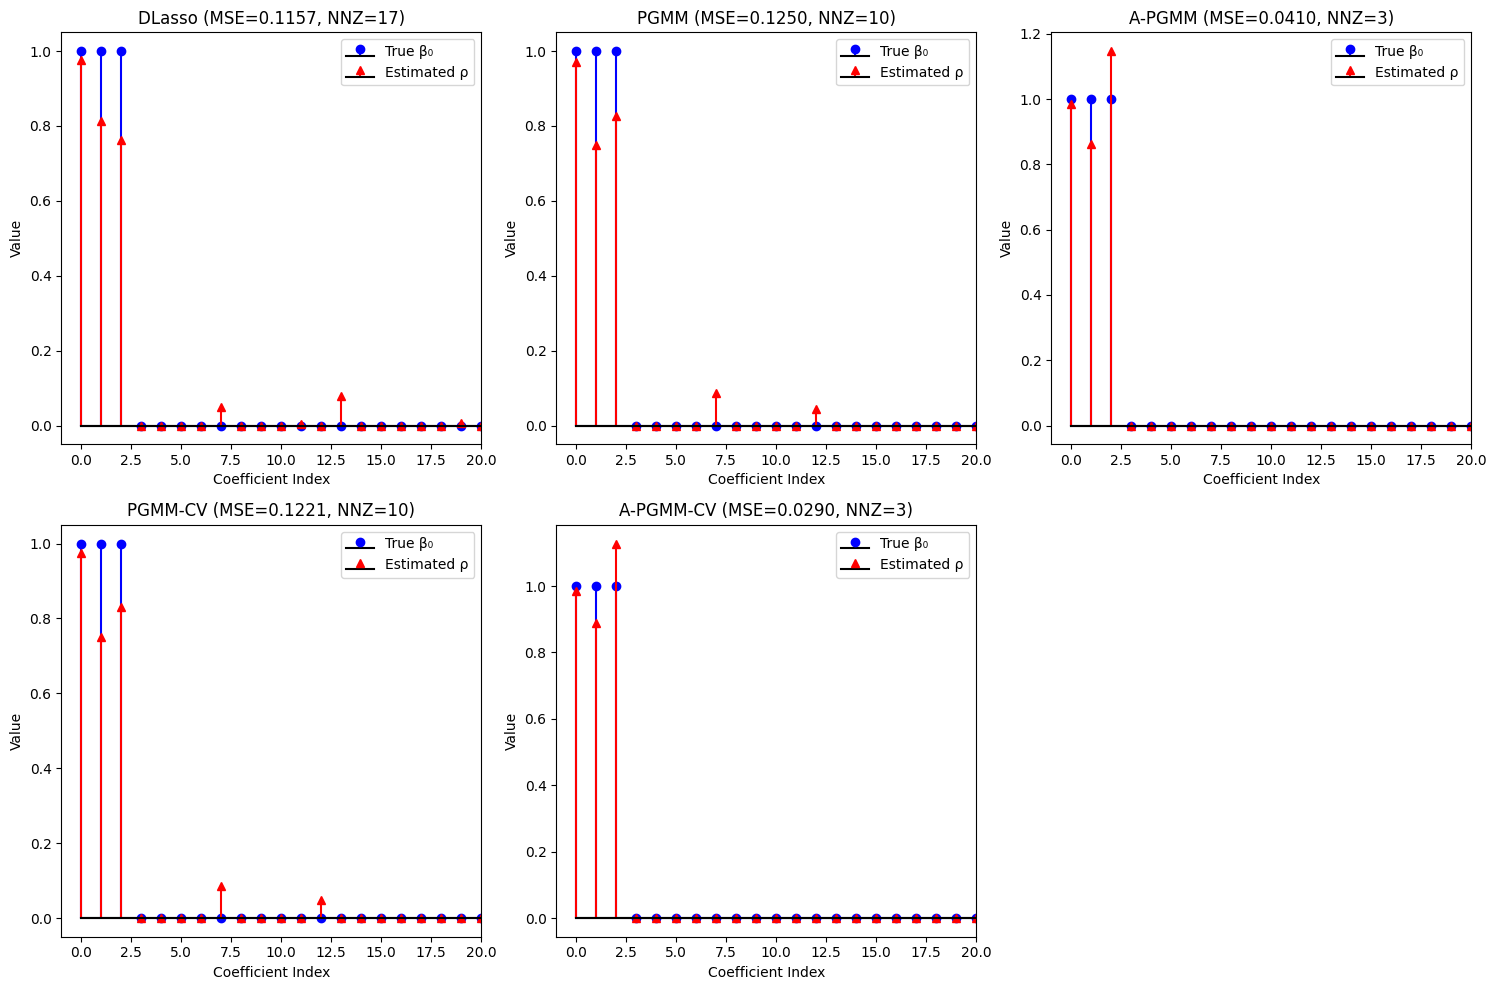

In [16]:
# Visualize coefficient estimates
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

methods = [
    ('DLasso', rho_dlasso),
    ('PGMM', rho_pgmm),
    ('A-PGMM', rho_apgmm),
    ('PGMM-CV', rho_pgmm_cv),
    ('A-PGMM-CV', rho_apgmm_cv)
]

for ax, (name, rho) in zip(axes.flat, methods):
    ax.stem(range(len(beta_0)), beta_0, linefmt='b-', markerfmt='bo', basefmt='k-', label='True β₀')
    ax.stem(range(len(rho)), rho, linefmt='r-', markerfmt='r^', basefmt='k-', label=f'Estimated ρ')
    ax.set_xlabel('Coefficient Index')
    ax.set_ylabel('Value')
    ax.set_title(f'{name} (MSE={np.sum((rho - beta_0)**2):.4f}, NNZ={np.count_nonzero(rho)})')
    ax.legend()
    ax.set_xlim(-1, 20)  # Focus on first 20 coefficients

# Hide the last subplot
axes.flat[-1].axis('off')

plt.tight_layout()
plt.show()

## 8. Monte Carlo Simulation

Run a full Monte Carlo study to compare methods across multiple replications.

In [17]:
# Configure Monte Carlo
config = MonteCarloConfig(
    n_runs=10,      # Number of replications (increase for more stable results)
    n_obs=1000,      # Sample size
    dx=100,         # Number of endogenous regressors
    dz=150,         # Number of instruments
    r=0.5,          # Endogeneity parameter
    seed=1111,      # Base random seed
    n_nonzero=3     # True non-zero coefficients
)

print(f"Monte Carlo Configuration:")
print(f"  n_runs:    {config.n_runs}")
print(f"  n_obs:     {config.n_obs}")
print(f"  dx:        {config.dx}")
print(f"  dz:        {config.dz}")
print(f"  r:         {config.r}")
print(f"  n_nonzero: {config.n_nonzero}")

Monte Carlo Configuration:
  n_runs:    10
  n_obs:     1000
  dx:        100
  dz:        150
  r:         0.5
  n_nonzero: 3


In [18]:
# Run Monte Carlo
mc = MonteCarloHDLinearIV(config=config, verbose=True)
results_df = mc.run()


Monte Carlo Simulation: HD Linear IV Regression
Number of replications: 10
Sample size: 1000
Number of parameters: 101
True non-zero coefficients: 3
Progress: 1/10 (10.0%) - Elapsed: 49.7s - ETA: 7.5m
Progress: 2/10 (20.0%) - Elapsed: 1.7m - ETA: 6.9m
Progress: 3/10 (30.0%) - Elapsed: 2.5m - ETA: 5.8m
Progress: 4/10 (40.0%) - Elapsed: 3.3m - ETA: 4.9m
Progress: 5/10 (50.0%) - Elapsed: 4.1m - ETA: 4.1m
Progress: 6/10 (60.0%) - Elapsed: 4.8m - ETA: 3.2m
Progress: 7/10 (70.0%) - Elapsed: 5.7m - ETA: 2.4m
Progress: 8/10 (80.0%) - Elapsed: 6.4m - ETA: 1.6m
Progress: 9/10 (90.0%) - Elapsed: 7.1m - ETA: 47.4s
Progress: 10/10 (100.0%) - Elapsed: 7.8m - ETA: 0.0s

Results Summary

Total time: 468.6 seconds (7.81 minutes)

Method         Mean MSE    Std MSE    Mean R²     Std R²
-------------------------------------------------------
DLasso           0.1078     0.0695     0.9524     0.0029
PGMM             0.1513     0.0961     0.9502     0.0041
PGMM-CV          0.1528     0.0969     0.9501    

In [19]:
# Display summary
print("\nMonte Carlo Summary:")
print(mc.get_summary())


Monte Carlo Summary:
           Mean MSE   Std MSE  Median MSE   Mean R²    Std R²  Median R²
Method                                                                  
DLasso     0.107846  0.069462    0.101802  0.952410  0.002904   0.952124
PGMM       0.151337  0.096093    0.158946  0.950190  0.004103   0.950720
PGMM-CV    0.152775  0.096949    0.158644  0.950126  0.004062   0.950234
A-PGMM     0.025316  0.011738    0.028468  0.954310  0.003273   0.954284
A-PGMM-CV  0.038454  0.024256    0.033840  0.953987  0.003242   0.953737


/var/folders/3g/wlsd318n60ddgb6y88hvy8gr0000gp/T/ipykernel_87838/2391926557.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(mse_data, labels=methods)
/var/folders/3g/wlsd318n60ddgb6y88hvy8gr0000gp/T/ipykernel_87838/2391926557.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(r2_data, labels=methods)


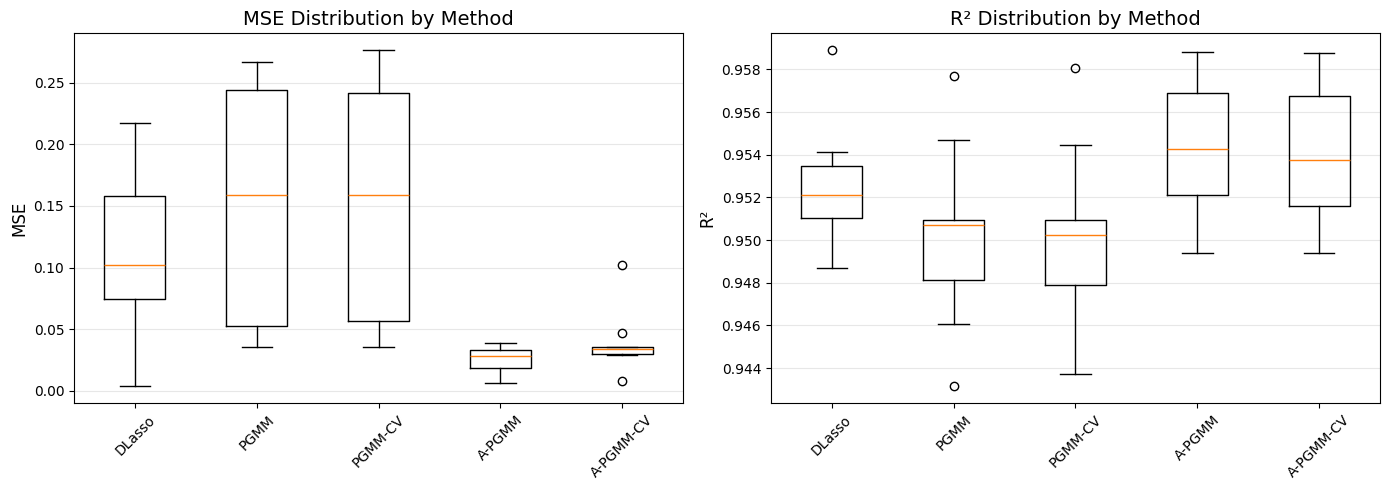

In [21]:
# Visualize MSE distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

methods = ['DLasso', 'PGMM', 'PGMM-CV', 'A-PGMM', 'A-PGMM-CV']
mse_cols = [f'{m}_MSE' for m in methods]
r2_cols = [f'{m}_R2' for m in methods]

# MSE boxplot
mse_data = [results_df[col].dropna() for col in mse_cols]
axes[0].boxplot(mse_data, labels=methods)
axes[0].set_ylabel('MSE', fontsize=12)
axes[0].set_title('MSE Distribution by Method', fontsize=14)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

# R² boxplot
r2_data = [results_df[col].dropna() for col in r2_cols]
axes[1].boxplot(r2_data, labels=methods)
axes[1].set_ylabel('R²', fontsize=12)
axes[1].set_title('R² Distribution by Method', fontsize=14)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [ ]:
# Save results
mc.save_results('mc_results.csv')  # Saves to mc_results_hd_linear_iv_n{n_obs}.csv

## 9. Varying Sample Size

Compare methods across different sample sizes to understand finite-sample behavior.

In [ ]:
# Run MC for different sample sizes
sample_sizes = [100, 500, 1000]
summaries = {}

for n in sample_sizes:
    print(f"\n{'='*70}")
    print(f"Running n = {n}")
    print(f"{'='*70}")
    
    config_n = MonteCarloConfig(
        n_runs=10,  # Quick run
        n_obs=n,
        dx=100,
        dz=150,
        r=0.5,
        seed=1111
    )
    
    mc_n = MonteCarloHDLinearIV(config=config_n, verbose=False)
    mc_n.run()
    summaries[n] = mc_n.get_summary()
    
    print(summaries[n][['Mean MSE', 'Mean R²']])

In [ ]:
# Plot MSE vs sample size
fig, ax = plt.subplots(figsize=(10, 6))

methods = ['DLasso', 'PGMM', 'PGMM-CV', 'A-PGMM', 'A-PGMM-CV']
colors = plt.cm.tab10(np.linspace(0, 1, len(methods)))

for method, color in zip(methods, colors):
    mse_values = [summaries[n].loc[method, 'Mean MSE'] for n in sample_sizes]
    ax.plot(sample_sizes, mse_values, 'o-', label=method, color=color, linewidth=2, markersize=8)

ax.set_xlabel('Sample Size (n)', fontsize=12)
ax.set_ylabel('Mean MSE', fontsize=12)
ax.set_title('MSE vs Sample Size (Linear IV Regression)', fontsize=14)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_xticks(sample_sizes)

plt.tight_layout()
plt.show()